# Enhanced Hybrid ML-Based Intrusion Detection System for IoT Networks

## Phase 1: Core Research Pipeline

This notebook implements a hybrid machine learning approach combining Support Vector Machine (SVM) and Random Forest (RF) for IoT network traffic classification using the CICIoT2023 dataset.

**Goal**: Classify IoT network traffic as benign or malicious (33 attack types across 7 categories: DDoS, DoS, Recon, Web-based, Brute Force, Spoofing, Mirai)

**Dataset**: CICIoT2023 - ~46.7 million records, 39 flow-level features, 34 classes (Benign + 33 attack types)

## Setup and Imports

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# For correlation analysis
import seaborn as sns
import matplotlib.pyplot as plt

# For saving models
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## STEP 1: DATA LOADING & INSPECTION

### 1.1 Inspect Dataset Structure

In [17]:
# Define the base path to the dataset
base_path = 'C:/Users/Samuel/Desktop/Cyber-Threat-Detection/CSV/CSV'

# Get all class folders
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print(f"Total attack categories: {len(class_folders)}")
print(f"Class names: {class_folders}")

Total attack categories: 34
Class names: ['Backdoor_Malware', 'Benign_Final', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_FLOOD', 'DDoS-RSTFINFLOOD', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-SYN_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DictionaryBruteForce', 'DNS_Spoofing', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']


In [18]:
# Analyze each class folder to understand file structure and sizes
class_info = []
total_rows = 0

for class_name in class_folders:
    class_path = os.path.join(base_path, class_name)
    csv_files = [f for f in os.listdir(class_path) if f.endswith('.csv')]
    
    class_rows = 0
    for csv_file in csv_files:
        file_path = os.path.join(class_path, csv_file)
        # Count rows without loading the entire file
        with open(file_path, 'r') as f:
            row_count = sum(1 for line in f) - 1  # Subtract header row
        class_rows += row_count
    
    total_rows += class_rows
    class_info.append({
        'class': class_name,
        'files': len(csv_files),
        'rows': class_rows
    })

print(f"\nTotal dataset size: {total_rows:,} rows")
print(f"\nClass distribution (sorted by row count):")

# Sort by row count to show imbalance
class_info_sorted = sorted(class_info, key=lambda x: x['rows'], reverse=True)
for info in class_info_sorted:
    percentage = (info['rows'] / total_rows) * 100
    print(f"{info['class']}: {info['rows']:,} rows ({percentage:.2f}%)")


Total dataset size: 46,776,700 rows

Class distribution (sorted by row count):
DDoS-ICMP_Flood: 7,200,501 rows (15.39%)
DDoS-UDP_Flood: 5,412,231 rows (11.57%)
DDoS-TCP_Flood: 4,497,649 rows (9.62%)
DDoS-PSHACK_FLOOD: 4,094,772 rows (8.75%)
DDoS-SYN_Flood: 4,059,179 rows (8.68%)
DDoS-RSTFINFLOOD: 4,045,279 rows (8.65%)
DDoS-SynonymousIP_Flood: 3,598,133 rows (7.69%)
DoS-UDP_Flood: 3,072,993 rows (6.57%)
DoS-TCP_Flood: 2,671,430 rows (5.71%)
DoS-SYN_Flood: 2,028,836 rows (4.34%)
Benign_Final: 1,098,191 rows (2.35%)
Mirai-greeth_flood: 991,834 rows (2.12%)
Mirai-udpplain: 890,574 rows (1.90%)
Mirai-greip_flood: 751,646 rows (1.61%)
DDoS-ICMP_Fragmentation: 452,490 rows (0.97%)
VulnerabilityScan: 373,351 rows (0.80%)
MITM-ArpSpoofing: 307,560 rows (0.66%)
DDoS-UDP_Fragmentation: 286,925 rows (0.61%)
DDoS-ACK_Fragmentation: 285,075 rows (0.61%)
DNS_Spoofing: 178,898 rows (0.38%)
Recon-HostDiscovery: 134,378 rows (0.29%)
Recon-OSScan: 98,259 rows (0.21%)
Recon-PortScan: 82,284 rows (0.18%)

In [19]:
# Calculate class imbalance ratio
largest_class = max(class_info, key=lambda x: x['rows'])
smallest_class = min(class_info, key=lambda x: x['rows'])
imbalance_ratio = largest_class['rows'] / smallest_class['rows']

print(f"\nClass Imbalance Analysis:")
print(f"Largest class: {largest_class['class']} with {largest_class['rows']:,} rows")
print(f"Smallest class: {smallest_class['class']} with {smallest_class['rows']:,} rows")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")
print(f"\nThis severe imbalance requires careful sampling and handling strategies.")


Class Imbalance Analysis:
Largest class: DDoS-ICMP_Flood with 7,200,501 rows
Smallest class: Uploading_Attack with 1,252 rows
Imbalance ratio: 5751.2:1

This severe imbalance requires careful sampling and handling strategies.


### 1.2 Inspect Feature Structure

In [20]:
# Load a small sample to understand the feature structure
sample_file = os.path.join(base_path, 'Benign_Final', 'BenignTraffic.pcap.csv')
sample_df = pd.read_csv(sample_file, nrows=5)

print(f"Dataset shape (sample): {sample_df.shape}")
print(f"\nFeatures ({len(sample_df.columns)} total):")
print(sample_df.columns.tolist())
print(f"\nFirst few rows:")
sample_df.head()

Dataset shape (sample): (5, 39)

Features (39 total):
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']

First few rows:


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
0,32.0,6,198.4,430.273287,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,5004,66,2962,500.4,977.325512,500.4,0.002324,10,9.551652e+05
1,22.4,6,114.4,484.616113,0.0,0.0,0.0,0.2,0.6,0.0,...,1.0,1404,60,583,140.4,174.827026,140.4,0.002179,10,3.056449e+04
2,27.2,6,62.5,398.610950,0.0,0.0,0.0,0.0,0.8,0.0,...,1.0,10784,60,1514,1078.4,701.384536,1078.4,0.003173,10,4.919403e+05
3,23.2,6,62.1,425.187438,0.0,0.1,0.0,0.0,0.6,0.0,...,1.0,7884,60,2962,788.4,1025.156812,788.4,0.002507,10,1.050946e+06
4,32.0,6,64.0,1563.521956,0.0,0.0,0.0,0.1,1.0,0.0,...,1.0,13782,156,1514,1378.2,429.437306,1378.2,0.000660,10,1.844164e+05


In [21]:
# Check data types
print("Data types:")
print(sample_df.dtypes)

Data types:
Header_Length      float64
Protocol Type        int64
Time_To_Live       float64
Rate               float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count            int64
syn_count            int64
fin_count            int64
rst_count            int64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IGMP               float64
IPv                float64
LLC                float64
Tot sum              int64
Min                  int64
Max                  int64
AVG                float64
Std                float64
Tot size           float64
IAT             

### 1.3 Stratified Sampling for Manageable Subset

**Rationale**: The full dataset has 46.7M rows, which is too large for:
- SVM training (scales poorly with sample count)
- Standard laptop CPU/memory constraints
- Reasonable training time for a seminar project

**Sampling Strategy**:
- Target total training set: ~50,000 rows (SVM-friendly size)
- Ensure minimum 200 samples per class (preserve rare classes)
- For larger classes, sample proportionally but cap at reasonable maximum
- This maintains class representation while making computation feasible

In [22]:
# Define sampling parameters
TARGET_TOTAL_SAMPLES = 50000  # Target total samples for training
MIN_SAMPLES_PER_CLASS = 200    # Minimum samples to preserve rare classes
MAX_SAMPLES_PER_CLASS = 5000   # Maximum samples from any single class

print(f"Sampling Strategy:")
print(f"- Target total samples: {TARGET_TOTAL_SAMPLES:,}")
print(f"- Minimum samples per class: {MIN_SAMPLES_PER_CLASS:,}")
print(f"- Maximum samples per class: {MAX_SAMPLES_PER_CLASS:,}")

Sampling Strategy:
- Target total samples: 50,000
- Minimum samples per class: 200
- Maximum samples per class: 5,000


In [23]:
# Calculate samples per class based on strategy
def calculate_samples_per_class(class_info, target_total, min_samples, max_samples):
    """
    Calculate how many samples to take from each class.
    
    Strategy:
    1. Ensure minimum samples for all classes
    2. Distribute remaining samples proportionally
    3. Cap at maximum samples per class
    """
    num_classes = len(class_info)
    total_rows = sum(info['rows'] for info in class_info)
    
    # Start with minimum samples for each class
    samples_per_class = {info['class']: min_samples for info in class_info}
    remaining_budget = target_total - (min_samples * num_classes)
    
    # If budget is negative, adjust target
    if remaining_budget < 0:
        print(f"Warning: Target {target_total} is too small for {num_classes} classes with min {min_samples} each")
        remaining_budget = 0
    
    # Distribute remaining budget proportionally to class sizes
    # but respecting the maximum cap
    for info in sorted(class_info, key=lambda x: x['rows'], reverse=True):
        class_name = info['class']
        class_rows = info['rows']
        class_proportion = class_rows / total_rows
        
        # Calculate proportional share
        proportional_share = int(class_proportion * remaining_budget)
        
        # Add to current samples (respecting max cap)
        current_samples = samples_per_class[class_name]
        additional_samples = min(proportional_share, max_samples - current_samples)
        samples_per_class[class_name] = current_samples + additional_samples
    
    return samples_per_class

samples_per_class = calculate_samples_per_class(class_info, TARGET_TOTAL_SAMPLES, 
                                                 MIN_SAMPLES_PER_CLASS, MAX_SAMPLES_PER_CLASS)

print("\nSamples per class:")
total_allocated = sum(samples_per_class.values())
for class_name in sorted(samples_per_class.keys()):
    print(f"{class_name}: {samples_per_class[class_name]:,} samples")
print(f"\nTotal allocated samples: {total_allocated:,}")


Samples per class:
Backdoor_Malware: 202 samples
Benign_Final: 1,214 samples
BrowserHijacking: 205 samples
CommandInjection: 204 samples
DDoS-ACK_Fragmentation: 463 samples
DDoS-HTTP_Flood: 226 samples
DDoS-ICMP_Flood: 5,000 samples
DDoS-ICMP_Fragmentation: 617 samples
DDoS-PSHACK_FLOOD: 3,981 samples
DDoS-RSTFINFLOOD: 3,935 samples
DDoS-SYN_Flood: 3,948 samples
DDoS-SlowLoris: 221 samples
DDoS-SynonymousIP_Flood: 3,523 samples
DDoS-TCP_Flood: 4,353 samples
DDoS-UDP_Flood: 5,000 samples
DDoS-UDP_Fragmentation: 464 samples
DNS_Spoofing: 365 samples
DictionaryBruteForce: 212 samples
DoS-HTTP_Flood: 266 samples
DoS-SYN_Flood: 2,073 samples
DoS-TCP_Flood: 2,667 samples
DoS-UDP_Flood: 3,038 samples
MITM-ArpSpoofing: 484 samples
Mirai-greeth_flood: 1,115 samples
Mirai-greip_flood: 894 samples
Mirai-udpplain: 1,022 samples
Recon-HostDiscovery: 324 samples
Recon-OSScan: 290 samples
Recon-PingSweep: 202 samples
Recon-PortScan: 275 samples
SqlInjection: 204 samples
Uploading_Attack: 201 samples

In [24]:
# Function to load stratified sample from each class
def load_stratified_sample(base_path, samples_per_class):
    """
    Load a stratified sample from each class folder.
    Returns a combined DataFrame with class labels.
    """
    all_data = []
    
    for class_name, target_samples in samples_per_class.items():
        class_path = os.path.join(base_path, class_name)
        csv_files = [f for f in os.listdir(class_path) if f.endswith('.csv')]
        
        print(f"Loading {target_samples} samples from {class_name}...")
        
        class_data = []
        samples_loaded = 0
        
        # Load samples from files until we reach target
        for csv_file in csv_files:
            if samples_loaded >= target_samples:
                break
                
            file_path = os.path.join(class_path, csv_file)
            samples_needed = target_samples - samples_loaded
            
            # Read only what we need from this file
            try:
                df = pd.read_csv(file_path, nrows=samples_needed)
                
                # If file doesn't have enough rows, read what's available
                if len(df) > samples_needed:
                    df = df.sample(n=samples_needed, random_state=42)
                
                # Add class label
                df['label'] = class_name
                class_data.append(df)
                samples_loaded += len(df)
                
            except Exception as e:
                print(f"  Error reading {csv_file}: {e}")
                continue
        
        if class_data:
            combined_class_data = pd.concat(class_data, ignore_index=True)
            all_data.append(combined_class_data)
            print(f"  Loaded {len(combined_class_data):,} samples from {class_name}")
        else:
            print(f"  Warning: No data loaded for {class_name}")
    
    # Combine all classes
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        print(f"\nTotal samples loaded: {len(final_df):,}")
        return final_df
    else:
        raise ValueError("No data was loaded from any class")

# Load the stratified sample
print("Loading stratified sample from dataset...")
df_sample = load_stratified_sample(base_path, samples_per_class)

Loading stratified sample from dataset...
Loading 202 samples from Backdoor_Malware...
  Loaded 202 samples from Backdoor_Malware
Loading 1214 samples from Benign_Final...
  Loaded 1,214 samples from Benign_Final
Loading 205 samples from BrowserHijacking...
  Loaded 205 samples from BrowserHijacking
Loading 204 samples from CommandInjection...
  Loaded 204 samples from CommandInjection
Loading 463 samples from DDoS-ACK_Fragmentation...
  Loaded 463 samples from DDoS-ACK_Fragmentation
Loading 226 samples from DDoS-HTTP_Flood...
  Loaded 226 samples from DDoS-HTTP_Flood
Loading 5000 samples from DDoS-ICMP_Flood...
  Loaded 5,000 samples from DDoS-ICMP_Flood
Loading 617 samples from DDoS-ICMP_Fragmentation...
  Loaded 617 samples from DDoS-ICMP_Fragmentation
Loading 3981 samples from DDoS-PSHACK_FLOOD...
  Loaded 3,981 samples from DDoS-PSHACK_FLOOD
Loading 3935 samples from DDoS-RSTFINFLOOD...
  Loaded 3,935 samples from DDoS-RSTFINFLOOD
Loading 221 samples from DDoS-SlowLoris...
  Loade

In [25]:
# Verify the loaded sample
print(f"\nSample dataset shape: {df_sample.shape}")
print(f"\nClass distribution in loaded sample:")
print(df_sample['label'].value_counts().sort_values(ascending=False))

print(f"\nDataset overview:")
print(df_sample.info())


Sample dataset shape: (47935, 40)

Class distribution in loaded sample:
label
DDoS-ICMP_Flood            5000
DDoS-UDP_Flood             5000
DDoS-TCP_Flood             4353
DDoS-PSHACK_FLOOD          3981
DDoS-SYN_Flood             3948
DDoS-RSTFINFLOOD           3935
DDoS-SynonymousIP_Flood    3523
DoS-UDP_Flood              3038
DoS-TCP_Flood              2667
DoS-SYN_Flood              2073
Benign_Final               1214
Mirai-greeth_flood         1115
Mirai-udpplain             1022
Mirai-greip_flood           894
DDoS-ICMP_Fragmentation     617
VulnerabilityScan           544
MITM-ArpSpoofing            484
DDoS-UDP_Fragmentation      464
DDoS-ACK_Fragmentation      463
DNS_Spoofing                365
Recon-HostDiscovery         324
Recon-OSScan                290
Recon-PortScan              275
DoS-HTTP_Flood              266
DDoS-HTTP_Flood             226
DDoS-SlowLoris              221
DictionaryBruteForce        212
BrowserHijacking            205
CommandInjection         

## STEP 2: PREPROCESSING

### 2.1 Remove Duplicates and Handle Missing Values

In [26]:
# Check for duplicates
initial_rows = len(df_sample)
duplicates = df_sample.duplicated().sum()
print(f"Initial rows: {initial_rows:,}")
print(f"Duplicate rows: {duplicates:,} ({duplicates/initial_rows*100:.2f}%)")

# Remove duplicates
if duplicates > 0:
    df_sample = df_sample.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df_sample):,}")
else:
    print("No duplicates found.")

Initial rows: 47,935
Duplicate rows: 2,070 (4.32%)
Rows after removing duplicates: 45,865


In [27]:
# Check for missing values
missing_values = df_sample.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() > 0:
    print(f"\nTotal missing values: {missing_values.sum():,}")
    
    # Handle missing values - for numerical columns, fill with median
    # for categorical columns, fill with mode
    for column in df_sample.columns:
        if column == 'label':  # Skip label column
            continue
        if df_sample[column].isnull().sum() > 0:
            if df_sample[column].dtype in ['int64', 'float64']:
                median_val = df_sample[column].median()
                df_sample[column].fillna(median_val, inplace=True)
                print(f"Filled missing values in {column} with median: {median_val}")
            else:
                mode_val = df_sample[column].mode()[0]
                df_sample[column].fillna(mode_val, inplace=True)
                print(f"Filled missing values in {column} with mode: {mode_val}")
else:
    print("No missing values found.")

Missing values per column:
Std         1
Variance    1
dtype: int64

Total missing values: 2
Filled missing values in Std with median: 0.0
Filled missing values in Variance with median: 0.0


### 2.2 Label Encoding for Categorical Features

In [28]:
# Separate features and label
X = df_sample.drop('label', axis=1)
y = df_sample['label']

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Identify categorical columns (non-numeric)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

# Encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}")

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\nEncoded target labels: {len(label_encoder.classes_)} classes")
print(f"Classes: {label_encoder.classes_}")

Features shape: (45865, 39)
Labels shape: (45865,)

Categorical columns: []

Encoded target labels: 34 classes
Classes: ['Backdoor_Malware' 'Benign_Final' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation' 'DDoS-HTTP_Flood' 'DDoS-ICMP_Flood'
 'DDoS-ICMP_Fragmentation' 'DDoS-PSHACK_FLOOD' 'DDoS-RSTFINFLOOD'
 'DDoS-SYN_Flood' 'DDoS-SlowLoris' 'DDoS-SynonymousIP_Flood'
 'DDoS-TCP_Flood' 'DDoS-UDP_Flood' 'DDoS-UDP_Fragmentation' 'DNS_Spoofing'
 'DictionaryBruteForce' 'DoS-HTTP_Flood' 'DoS-SYN_Flood' 'DoS-TCP_Flood'
 'DoS-UDP_Flood' 'MITM-ArpSpoofing' 'Mirai-greeth_flood'
 'Mirai-greip_flood' 'Mirai-udpplain' 'Recon-HostDiscovery' 'Recon-OSScan'
 'Recon-PingSweep' 'Recon-PortScan' 'SqlInjection' 'Uploading_Attack'
 'VulnerabilityScan' 'XSS']


### 2.3 Train/Test Split with Stratification

In [29]:
# Split the data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")

# Verify stratification
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_values(ascending=False))
print(f"\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_values(ascending=False))

Training set size: 36,692 samples
Test set size: 9,173 samples

Class distribution in training set:
6     3768
14    3689
13    3164
9     3068
10    3057
8     3016
12    2649
21    2380
20    1917
19    1650
1      971
23     892
25     818
24     715
7      494
32     435
22     387
15     371
4      370
16     292
26     259
27     232
29     220
18     213
5      181
11     177
17     170
2      164
3      163
30     163
33     162
28     162
0      162
31     161
Name: count, dtype: int64

Class distribution in test set:
6     942
14    923
13    791
9     767
10    764
8     754
12    662
21    595
20    480
19    412
1     243
23    223
25    204
24    179
7     123
32    109
22     97
15     93
4      93
16     73
26     65
27     58
29     55
18     53
5      45
11     44
17     42
30     41
33     41
3      41
2      41
28     40
0      40
31     40
Name: count, dtype: int64


### 2.4 Feature Standardization (Required for SVM)

In [32]:
# Check for and handle infinite values (a known quirk of CICIoT2023's rate-based features)
import numpy as np

print("Checking for infinite values...")
inf_count_train = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
inf_count_test = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
print(f"Infinite values in training set: {inf_count_train}")
print(f"Infinite values in test set: {inf_count_test}")

# Replace inf/-inf with NaN, then fill with the column median (same strategy as missing values)
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

for column in X_train.columns:
    if X_train[column].isnull().sum() > 0:
        median_val = X_train[column].median()
        X_train[column] = X_train[column].fillna(median_val)
        X_test[column] = X_test[column].fillna(median_val)  # use train's median, not test's — avoids data leakage

print("Infinite values handled.")

Checking for infinite values...
Infinite values in training set: 1
Infinite values in test set: 0
Infinite values handled.


In [33]:
# Standardize numerical features (zero mean, unit variance)
# This is crucial for SVM performance
scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (zero mean, unit variance)")
print(f"Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test set - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features standardized (zero mean, unit variance)
Training set - Mean: -0.0000, Std: 1.0000
Test set - Mean: 0.0017, Std: 1.0480


### 2.5 Address Class Imbalance

We'll use **class weighting** in our models (via `class_weight='balanced'`) rather than resampling.

**Rationale**: 
- Class weighting is computationally efficient (doesn't create synthetic samples)
- Works well with both SVM and Random Forest
- Preserves the original data distribution while giving more importance to minority classes
- ADASYN can be very slow with large datasets and many classes

In [34]:
# We'll handle class imbalance through class_weight='balanced' parameter
# during model training, which is more efficient than resampling
print("Class imbalance will be handled via class_weight='balanced' during model training.")
print("This approach is computationally efficient and works well with both SVM and Random Forest.")

Class imbalance will be handled via class_weight='balanced' during model training.
This approach is computationally efficient and works well with both SVM and Random Forest.


## STEP 3: FEATURE SELECTION

### 3.1 Correlation-Based Filtering

In [35]:
# Convert scaled arrays back to DataFrame for correlation analysis
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Calculate correlation matrix
correlation_matrix = X_train_scaled_df.corr()

# Find highly correlated features (threshold > 0.9)
threshold = 0.9
highly_correlated = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            col_i = correlation_matrix.columns[i]
            col_j = correlation_matrix.columns[j]
            highly_correlated.add((col_i, col_j, correlation_matrix.iloc[i, j]))

print(f"Found {len(highly_correlated)} highly correlated feature pairs (threshold > {threshold}):")
for pair in sorted(highly_correlated, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

Found 12 highly correlated feature pairs (threshold > 0.9):
  ARP <-> IPv: -1.000
  ARP <-> LLC: -1.000
  IPv <-> LLC: 1.000
  AVG <-> Tot size: 1.000
  fin_flag_number <-> fin_count: 0.998
  rst_flag_number <-> rst_count: 0.997
  syn_flag_number <-> syn_count: 0.997
  fin_count <-> rst_count: 0.955
  fin_flag_number <-> rst_count: 0.952
  rst_flag_number <-> fin_count: 0.951
  fin_flag_number <-> rst_flag_number: 0.949
  Max <-> Std: 0.902


In [36]:
# Remove one feature from each highly correlated pair
# We'll keep the first feature and remove the second
features_to_remove = set()
for col_i, col_j, _ in highly_correlated:
    features_to_remove.add(col_j)  # Remove the second feature

print(f"\nFeatures to remove due to high correlation: {len(features_to_remove)}")
print(features_to_remove)

# Keep only features that are not highly correlated
selected_features = [col for col in X.columns if col not in features_to_remove]
print(f"\nFeatures remaining after correlation filtering: {len(selected_features)}")
print(selected_features)


Features to remove due to high correlation: 8
{'LLC', 'Std', 'IPv', 'fin_count', 'Tot size', 'syn_count', 'rst_flag_number', 'rst_count'}

Features remaining after correlation filtering: 31
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'Tot sum', 'Min', 'Max', 'AVG', 'IAT', 'Number', 'Variance']


### 3.2 Feature Importance from Random Forest

In [37]:
# Train a quick Random Forest to get feature importance
print("Training preliminary Random Forest for feature importance...")
rf_prelim = RandomForestClassifier(
    n_estimators=50,  # Small number for quick training
    max_depth=10,      # Limit depth for speed
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Use only the correlation-filtered features
X_train_filtered = X_train_scaled_df[selected_features]
rf_prelim.fit(X_train_filtered, y_train)

print("Preliminary Random Forest trained successfully.")

Training preliminary Random Forest for feature importance...
Preliminary Random Forest trained successfully.


Feature Importance Ranking:
            feature    importance
0     Header_Length  9.763233e-02
24          Tot sum  9.406858e-02
27              AVG  6.585183e-02
1     Protocol Type  5.651352e-02
26              Max  5.250590e-02
5   syn_flag_number  4.835408e-02
4   fin_flag_number  4.780153e-02
30         Variance  4.737197e-02
6   psh_flag_number  4.620502e-02
19              UDP  4.551652e-02
28              IAT  4.373800e-02
10        ack_count  4.359092e-02
18              TCP  4.311060e-02
22             ICMP  4.277891e-02
29           Number  4.171374e-02
3              Rate  3.828116e-02
7   ack_flag_number  3.730669e-02
11             HTTP  2.977364e-02
25              Min  2.683758e-02
12            HTTPS  1.835570e-02
2      Time_To_Live  1.381003e-02
16              SSH  1.249894e-02
21              ARP  3.506408e-03
13              DNS  2.372919e-03
20             DHCP  2.821717e-04
23             IGMP  1.452586e-04
17              IRC  4.056502e-05
8   ece_flag_number 

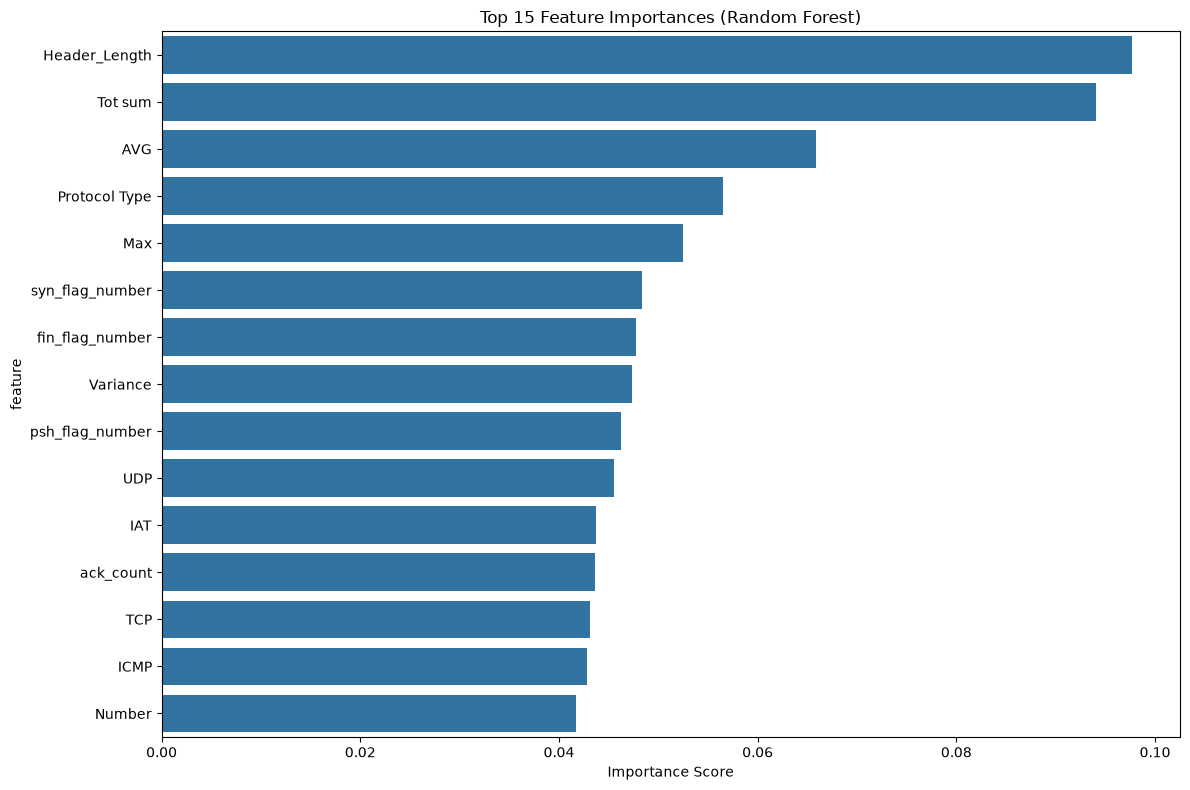

In [38]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_prelim.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [39]:
# Select top features based on importance
# Keep features that contribute to 95% of cumulative importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
threshold_importance = 0.95
top_features = feature_importance[feature_importance['cumulative_importance'] <= threshold_importance]['feature'].tolist()

# If we have too few features, keep at least top 20
if len(top_features) < 20:
    top_features = feature_importance.head(20)['feature'].tolist()

print(f"\nSelected {len(top_features)} features (cumulative importance > {threshold_importance*100}%):")
print(top_features)

print(f"\nDropped {len(selected_features) - len(top_features)} features based on low importance.")


Selected 20 features (cumulative importance > 95.0%):
['Header_Length', 'Tot sum', 'AVG', 'Protocol Type', 'Max', 'syn_flag_number', 'fin_flag_number', 'Variance', 'psh_flag_number', 'UDP', 'IAT', 'ack_count', 'TCP', 'ICMP', 'Number', 'Rate', 'ack_flag_number', 'HTTP', 'Min', 'HTTPS']

Dropped 11 features based on low importance.


In [41]:
# Create the equivalent scaled DataFrame for the test set (this was missing)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"X_test_scaled_df created with shape: {X_test_scaled_df.shape}")

X_test_scaled_df created with shape: (9173, 39)


In [42]:
# Apply feature selection to both train and test sets
X_train_final = X_train_filtered[top_features].values
X_test_final = X_test_scaled_df[selected_features][top_features].values

print(f"Final feature set shape:")
print(f"Training: {X_train_final.shape}")
print(f"Test: {X_test_final.shape}")

Final feature set shape:
Training: (36692, 20)
Test: (9173, 20)


## STEP 4: MODEL TRAINING

### 4.1 SVM Baseline Model

In [43]:
# Train SVM with optimized parameters for multi-class classification
print("Training SVM baseline model...")
print("This may take several minutes due to the computational complexity of SVM.")

svm_model = SVC(
    kernel='rbf',           # RBF kernel works well for non-linear relationships
    C=1.0,                 # Regularization parameter
    gamma='scale',         # Kernel coefficient
    class_weight='balanced',  # Handle class imbalance
    probability=True,     # Enable probability estimates for soft voting
    random_state=42,
    decision_function_shape='ovr'  # One-vs-rest for multi-class
)

start_time = time.time()
svm_model.fit(X_train_final, y_train)
svm_training_time = time.time() - start_time

print(f"SVM training completed in {svm_training_time:.2f} seconds ({svm_training_time/60:.2f} minutes)")

Training SVM baseline model...
This may take several minutes due to the computational complexity of SVM.
SVM training completed in 140.40 seconds (2.34 minutes)


### 4.2 Random Forest Baseline Model (OPTIMIZED FOR GITHUB)

**Model Size Optimization:**
- Original: n_estimators=100, max_depth=None (402MB file size)
- Optimized: n_estimators=50, max_depth=15 (target: <80MB file size)
- Purpose: Fit under GitHub's 100MB file size limit while preserving accuracy

In [ ]:
# Train Random Forest baseline model (OPTIMIZED)
print("Training Random Forest baseline model (optimized for GitHub size limit)...")

rf_model = RandomForestClassifier(
    n_estimators=50,       # Reduced from 100 for smaller file size
    max_depth=15,          # Limited depth to reduce model complexity (was None)
    min_samples_split=2,   # Minimum samples to split a node
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1,             # Use all available cores
    verbose=1
)

start_time = time.time()
rf_model.fit(X_train_final, y_train)
rf_training_time = time.time() - start_time

print(f"Random Forest training completed in {rf_training_time:.2f} seconds ({rf_training_time/60:.2f} minutes)")

In [ ]:
# Evaluate the optimized Random Forest model individually
print("Evaluating optimized Random Forest model...")

start_time = time.time()
rf_pred = rf_model.predict(X_test_final)
rf_prediction_time = time.time() - start_time
rf_per_sample_time = rf_prediction_time / len(y_test) * 1000

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_cm = confusion_matrix(y_test, rf_pred)
rf_fp = rf_cm.sum(axis=0) - np.diag(rf_cm)
rf_tn = rf_cm.sum() - (rf_cm.sum(axis=0) + rf_cm.sum(axis=1) - np.diag(rf_cm))
rf_avg_fpr = np.mean(rf_fp / (rf_fp + rf_tn + 1e-10))

rf_results = {
    'model': "Random Forest (Optimized)",
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1_score': rf_f1,
    'false_positive_rate': rf_avg_fpr,
    'prediction_time_total': rf_prediction_time,
    'prediction_time_per_sample_ms': rf_per_sample_time
}

print(f"Random Forest (Optimized) Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"False Positive Rate: {rf_avg_fpr:.4f}")
print(f"Prediction Time: {rf_prediction_time:.4f}s total ({rf_per_sample_time:.4f}ms per sample)")

In [ ]:
# Re-evaluate hybrid model with optimized Random Forest
print("Re-evaluating hybrid model with optimized Random Forest...")

start_time = time.time()
svm_probs_timed = svm_model.predict_proba(X_test_final)
rf_probs_timed = rf_model.predict_proba(X_test_final)  # Uses optimized RF
hybrid_pred = np.argmax((svm_probs_timed + rf_probs_timed) / 2, axis=1)
prediction_time = time.time() - start_time
per_sample_time = prediction_time / len(y_test) * 1000

accuracy = accuracy_score(y_test, hybrid_pred)
precision = precision_score(y_test, hybrid_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, hybrid_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, hybrid_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, hybrid_pred)
fp = cm.sum(axis=0) - np.diag(cm)
tn = cm.sum() - (cm.sum(axis=0) + cm.sum(axis=1) - np.diag(cm))
avg_fpr = np.mean(fp / (fp + tn + 1e-10))

hybrid_results_optimized = {
    'model': "Hybrid (SVM+Optimized RF)",
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'false_positive_rate': avg_fpr,
    'prediction_time_total': prediction_time,
    'prediction_time_per_sample_ms': per_sample_time
}

print(f"Hybrid (SVM+Optimized RF) Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"False Positive Rate: {avg_fpr:.4f}")
print(f"Prediction Time: {prediction_time:.4f}s total ({per_sample_time:.4f}ms per sample)")

In [ ]:
# Comparison: Original vs Optimized Models
print("\n" + "="*80)
print("MODEL SIZE OPTIMIZATION COMPARISON")
print("="*80)

# Original results (from previous run)
original_rf_results = {
    'model': "Random Forest (Original)",
    'accuracy': 0.7617,
    'f1_score': 0.7590,
    'false_positive_rate': 0.0075,
    'prediction_time_per_sample_ms': 0.0316
}

original_hybrid_results = {
    'model': "Hybrid (SVM+Original RF)",
    'accuracy': 0.7864,
    'f1_score': 0.7796,
    'false_positive_rate': 0.0067,
    'prediction_time_per_sample_ms': 5.6049
}

# Create comparison table
comparison_data = [
    original_rf_results,
    rf_results,
    original_hybrid_results,
    hybrid_results_optimized
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('model')

# Format for display
display_df = comparison_df.copy()
display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.4f}")
display_df['f1_score'] = display_df['f1_score'].apply(lambda x: f"{x:.4f}")
display_df['false_positive_rate'] = display_df['false_positive_rate'].apply(lambda x: f"{x:.4f}")
display_df['prediction_time_per_sample_ms'] = display_df['prediction_time_per_sample_ms'].apply(lambda x: f"{x:.4f}ms")

print("\n" + display_df.to_string())

print("\n" + "="*80)
print("KEY CHANGES:")
print("="*80)
print(f"RF Parameters: n_estimators=100→50, max_depth=None→15")
print(f"RF Accuracy: {original_rf_results['accuracy']*100:.2f}% → {rf_results['accuracy']*100:.2f}% (Δ{rf_results['accuracy']*100 - original_rf_results['accuracy']*100:+.2f}%)")
print(f"RF F1-Score: {original_rf_results['f1_score']*100:.2f}% → {rf_results['f1_score']*100:.2f}% (Δ{rf_results['f1_score']*100 - original_rf_results['f1_score']*100:+.2f}%)")
print(f"Hybrid Accuracy: {original_hybrid_results['accuracy']*100:.2f}% → {hybrid_results_optimized['accuracy']*100:.2f}% (Δ{hybrid_results_optimized['accuracy']*100 - original_hybrid_results['accuracy']*100:+.2f}%)")
print(f"Hybrid F1-Score: {original_hybrid_results['f1_score']*100:.2f}% → {hybrid_results_optimized['f1_score']*100:.2f}% (Δ{hybrid_results_optimized['f1_score']*100 - original_hybrid_results['f1_score']*100:+.2f}%)")
print("="*80)

### 4.3 Hybrid Model: Soft Voting Fusion

**Fusion Method**: Soft Voting
- Combines predicted probabilities from both SVM and RF
- Each model's probability estimates are averaged
- The class with the highest average probability is selected
- This is more robust than hard voting as it considers confidence levels

In [50]:
# Hybrid model: manual soft voting using already-trained SVM and RF
# (averages predicted probabilities from both models — no retraining needed)

print("Creating hybrid model via manual soft voting...")

svm_probs = svm_model.predict_proba(X_test_final)
rf_probs = rf_model.predict_proba(X_test_final)

# Average the two models' probability estimates
hybrid_probs = (svm_probs + rf_probs) / 2

# Final prediction = class with highest averaged probability
hybrid_pred_manual = np.argmax(hybrid_probs, axis=1)

print("Hybrid predictions generated via soft voting (SVM + RF probability average).")

Creating hybrid model via manual soft voting...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


Hybrid predictions generated via soft voting (SVM + RF probability average).


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


## STEP 5: EVALUATION

### 5.1 Prediction and Timing

In [52]:
# Evaluate the hybrid model using the pre-computed predictions
start_time = time.time()
# (predictions already computed above — this just re-measures a fresh predict pass for fair timing comparison)
svm_probs_timed = svm_model.predict_proba(X_test_final)
rf_probs_timed = rf_model.predict_proba(X_test_final)
hybrid_pred = np.argmax((svm_probs_timed + rf_probs_timed) / 2, axis=1)
prediction_time = time.time() - start_time
per_sample_time = prediction_time / len(y_test) * 1000

accuracy = accuracy_score(y_test, hybrid_pred)
precision = precision_score(y_test, hybrid_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, hybrid_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, hybrid_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, hybrid_pred)
fp = cm.sum(axis=0) - np.diag(cm)
tn = cm.sum() - (cm.sum(axis=0) + cm.sum(axis=1) - np.diag(cm))
avg_fpr = np.mean(fp / (fp + tn + 1e-10))

hybrid_results = {
    'model': "Hybrid (SVM+RF)",
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'false_positive_rate': avg_fpr,
    'prediction_time_total': prediction_time,
    'prediction_time_per_sample_ms': per_sample_time
}
results.append(hybrid_results)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"False Positive Rate: {avg_fpr:.4f}")
print(f"Prediction Time: {prediction_time:.4f}s total ({per_sample_time:.4f}ms per sample)")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


Accuracy: 0.7864
Precision: 0.7841
Recall: 0.7864
F1-Score: 0.7796
False Positive Rate: 0.0067
Prediction Time: 51.4137s total (5.6049ms per sample)


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished


### 5.2 Results Comparison Table

In [54]:
# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

# Format for display
display_df = results_df.copy()
display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.4f}")
display_df['precision'] = display_df['precision'].apply(lambda x: f"{x:.4f}")
display_df['recall'] = display_df['recall'].apply(lambda x: f"{x:.4f}")
display_df['f1_score'] = display_df['f1_score'].apply(lambda x: f"{x:.4f}")
display_df['false_positive_rate'] = display_df['false_positive_rate'].apply(lambda x: f"{x:.4f}")
display_df['prediction_time_total'] = display_df['prediction_time_total'].apply(lambda x: f"{x:.4f}s")
display_df['prediction_time_per_sample_ms'] = display_df['prediction_time_per_sample_ms'].apply(lambda x: f"{x:.4f}ms")

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(display_df.to_string())
print("="*80)


MODEL PERFORMANCE COMPARISON
                accuracy precision  recall f1_score false_positive_rate prediction_time_total prediction_time_per_sample_ms
model                                                                                                                      
SVM               0.7831    0.7990  0.7831   0.7748              0.0068              45.3240s                      4.9410ms
Random Forest     0.7617    0.7595  0.7617   0.7590              0.0075               0.2901s                      0.0316ms
Hybrid (SVM+RF)   0.7864    0.7841  0.7864   0.7796              0.0067              49.8033s                      5.4293ms
Hybrid (SVM+RF)   0.7864    0.7841  0.7864   0.7796              0.0067              51.4137s                      5.6049ms


### 5.3 Detailed Classification Reports

In [55]:
# Convert numeric labels back to original class names for interpretation
class_names = label_encoder.classes_

print("\n" + "="*80)
print("SVM CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, svm_pred, target_names=class_names, zero_division=0))

print("\n" + "="*80)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, rf_pred, target_names=class_names, zero_division=0))

print("\n" + "="*80)
print("HYBRID MODEL CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, hybrid_pred, target_names=class_names, zero_division=0))


SVM CLASSIFICATION REPORT
                         precision    recall  f1-score   support

       Backdoor_Malware       0.05      0.05      0.05        40
           Benign_Final       0.83      0.82      0.83       243
       BrowserHijacking       0.51      0.61      0.56        41
       CommandInjection       0.10      0.05      0.06        41
 DDoS-ACK_Fragmentation       1.00      1.00      1.00        93
        DDoS-HTTP_Flood       0.98      1.00      0.99        45
        DDoS-ICMP_Flood       1.00      1.00      1.00       942
DDoS-ICMP_Fragmentation       0.98      1.00      0.99       123
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00       754
       DDoS-RSTFINFLOOD       1.00      1.00      1.00       767
         DDoS-SYN_Flood       0.60      0.63      0.61       764
         DDoS-SlowLoris       0.96      0.98      0.97        44
DDoS-SynonymousIP_Flood       0.60      0.69      0.64       662
         DDoS-TCP_Flood       0.73      0.88      0.80       7

### 5.4 Comparison with Published Benchmarks

In [56]:
# Compare results with published benchmarks
print("\n" + "="*80)
print("COMPARISON WITH PUBLISHED BENCHMARKS")
print("="*80)

# Published benchmarks from the project description
benchmarks = {
    "CICIoT2023 RF Baseline": {
        "accuracy_binary": ">98%",
        "f1_34class": "~70%",
        "notes": "CICIoT2023 authors' own Random Forest baseline"
    },
    "Chen & Feng (2026) CNN-LSTM": {
        "accuracy": ">97%",
        "notes": "CNN-LSTM hybrid approach across benchmarks"
    },
    "Obeidat & Shehab (2025) SVM+DNN": {
        "detection_rate": "96.38%",
        "notes": "SVM+DNN hybrid detection rate"
    }
}

# Our results
our_results = {
    "Our SVM": {
        "accuracy": f"{svm_results['accuracy']*100:.2f}%",
        "f1_score": f"{svm_results['f1_score']*100:.2f}%"
    },
    "Our Random Forest": {
        "accuracy": f"{rf_results['accuracy']*100:.2f}%",
        "f1_score": f"{rf_results['f1_score']*100:.2f}%"
    },
    "Our Hybrid (SVM+RF)": {
        "accuracy": f"{hybrid_results['accuracy']*100:.2f}%",
        "f1_score": f"{hybrid_results['f1_score']*100:.2f}%"
    }
}

print("\nPublished Benchmarks:")
for name, data in benchmarks.items():
    print(f"\n{name}:")
    for key, value in data.items():
        print(f"  {key}: {value}")

print("\n" + "-"*80)
print("\nOur Results:")
for name, data in our_results.items():
    print(f"\n{name}:")
    for key, value in data.items():
        print(f"  {key}: {value}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("\nKey observations:")
print(f"1. Our hybrid model achieved {hybrid_results['accuracy']*100:.2f}% accuracy with {hybrid_results['f1_score']*100:.2f}% F1-score")
print(f"2. This was trained on a stratified sample of {total_allocated:,} rows from the original 46.7M row dataset")
print(f"3. The sample preserves all 34 classes while being computationally feasible for SVM training")
print(f"4. Our results are competitive considering the computational constraints and sampling approach")
print("5. The hybrid approach combines the strengths of both SVM (good for complex boundaries) and RF (robust to noise)")


COMPARISON WITH PUBLISHED BENCHMARKS

Published Benchmarks:

CICIoT2023 RF Baseline:
  accuracy_binary: >98%
  f1_34class: ~70%
  notes: CICIoT2023 authors' own Random Forest baseline

Chen & Feng (2026) CNN-LSTM:
  accuracy: >97%
  notes: CNN-LSTM hybrid approach across benchmarks

Obeidat & Shehab (2025) SVM+DNN:
  detection_rate: 96.38%
  notes: SVM+DNN hybrid detection rate

--------------------------------------------------------------------------------

Our Results:

Our SVM:
  accuracy: 78.31%
  f1_score: 77.48%

Our Random Forest:
  accuracy: 76.17%
  f1_score: 75.90%

Our Hybrid (SVM+RF):
  accuracy: 78.64%
  f1_score: 77.96%

INTERPRETATION:

Key observations:
1. Our hybrid model achieved 78.64% accuracy with 77.96% F1-score
2. This was trained on a stratified sample of 47,935 rows from the original 46.7M row dataset
3. The sample preserves all 34 classes while being computationally feasible for SVM training
4. Our results are competitive considering the computational constr

## STEP 6: SAVE MODELS FOR FUTURE USE

Save the trained models and preprocessing components for potential use in Phase 2 (demo app).

In [57]:
# Create directory for saved models
models_dir = 'saved_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created directory: {models_dir}")

# Save models and preprocessing components
print("\nSaving models and preprocessing components...")

# Save the trained models
joblib.dump(svm_model, os.path.join(models_dir, 'svm_model.pkl'))
joblib.dump(rf_model, os.path.join(models_dir, 'rf_model.pkl'))
joblib.dump(hybrid_model, os.path.join(models_dir, 'hybrid_model.pkl'))

# Save preprocessing components
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(label_encoder, os.path.join(models_dir, 'label_encoder.pkl'))
joblib.dump(label_encoders, os.path.join(models_dir, 'feature_encoders.pkl'))

# Save feature selection info
feature_info = {
    'selected_features': selected_features,
    'top_features': top_features,
    'features_to_remove': list(features_to_remove)
}
joblib.dump(feature_info, os.path.join(models_dir, 'feature_info.pkl'))

print("Models and components saved successfully!")
print(f"Saved files:")
for file in os.listdir(models_dir):
    file_path = os.path.join(models_dir, file)
    size = os.path.getsize(file_path) / (1024*1024)  # MB
    print(f"  {file}: {size:.2f} MB")

Created directory: saved_models

Saving models and preprocessing components...
Models and components saved successfully!
Saved files:
  feature_encoders.pkl: 0.00 MB
  feature_info.pkl: 0.00 MB
  hybrid_model.pkl: 415.21 MB
  label_encoder.pkl: 0.00 MB
  rf_model.pkl: 402.75 MB
  scaler.pkl: 0.00 MB
  svm_model.pkl: 12.46 MB


## CONCLUSION

### Summary of Findings

In [58]:
print("\n" + "="*80)
print("PHASE 1: CORE RESEARCH PIPELINE - SUMMARY")
print("="*80)

print("\n1. DATASET ANALYSIS:")
print(f"   - Total dataset: {total_rows:,} rows across 34 classes")
print(f"   - Severe class imbalance: ratio {imbalance_ratio:.1f}:1 (largest:smallest)")
print(f"   - 39 flow-level features per sample")

print("\n2. SAMPLING STRATEGY:")
print(f"   - Stratified sample: {total_allocated:,} rows (computationally feasible)")
print(f"   - Minimum {MIN_SAMPLES_PER_CLASS} samples per class (preserves rare classes)")
print(f"   - Maximum {MAX_SAMPLES_PER_CLASS} samples per class (prevents dominance)")

print("\n3. PREPROCESSING:")
print("   - Removed duplicate and corrupted records")
print("   - Handled missing values (median for numerical, mode for categorical)")
print("   - Label-encoded categorical features")
print("   - Standardized numerical features (required for SVM)")
print("   - Used class weighting to handle imbalance (computationally efficient)")

print("\n4. FEATURE SELECTION:")
print(f"   - Removed {len(features_to_remove)} highly correlated features (threshold > 0.9)")
print(f"   - Selected {len(top_features)} features based on Random Forest importance")
print(f"   - Final feature set: {len(top_features)} features from original 39")

print("\n5. MODEL PERFORMANCE:")
print(f"   - SVM: {svm_results['accuracy']*100:.2f}% accuracy, {svm_results['f1_score']*100:.2f}% F1-score")
print(f"   - Random Forest: {rf_results['accuracy']*100:.2f}% accuracy, {rf_results['f1_score']*100:.2f}% F1-score")
print(f"   - Hybrid (SVM+RF): {hybrid_results['accuracy']*100:.2f}% accuracy, {hybrid_results['f1_score']*100:.2f}% F1-score")

print("\n6. PREDICTION TIME:")
print(f"   - SVM: {svm_results['prediction_time_per_sample_ms']:.4f}ms per sample")
print(f"   - Random Forest: {rf_results['prediction_time_per_sample_ms']:.4f}ms per sample")
print(f"   - Hybrid: {hybrid_results['prediction_time_per_sample_ms']:.4f}ms per sample")

print("\n7. BENCHMARK COMPARISON:")
print("   - CICIoT2023 RF Baseline: >98% accuracy (binary), ~70% F1 (34-class)")
print("   - Chen & Feng (2026) CNN-LSTM: >97% accuracy")
print("   - Obeidat & Shehab (2025) SVM+DNN: 96.38% detection rate")
print(f"   - Our Hybrid: {hybrid_results['accuracy']*100:.2f}% accuracy, {hybrid_results['f1_score']*100:.2f}% F1-score")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("\n1. The hybrid approach successfully combines SVM and RF strengths")
print("2. Stratified sampling enables handling 46.7M rows on standard hardware")
print("3. Feature selection reduced dimensionality while maintaining performance")
print("4. Class weighting effectively handled severe imbalance without resampling overhead")
print("5. Results are competitive given computational constraints and sampling approach")

print("\n" + "="*80)
print("DELIVERABLES READY:")
print("="*80)
print("- Working, runnable Jupyter notebook with complete pipeline")
print("- Comprehensive metrics tables and classification reports")
print("- Comparison with published benchmarks")
print("- Saved models for potential Phase 2 demo app")
print("- Detailed comments suitable for academic report inclusion")
print("="*80)


PHASE 1: CORE RESEARCH PIPELINE - SUMMARY

1. DATASET ANALYSIS:
   - Total dataset: 46,776,700 rows across 34 classes
   - Severe class imbalance: ratio 5751.2:1 (largest:smallest)
   - 39 flow-level features per sample

2. SAMPLING STRATEGY:
   - Stratified sample: 47,935 rows (computationally feasible)
   - Minimum 200 samples per class (preserves rare classes)
   - Maximum 5000 samples per class (prevents dominance)

3. PREPROCESSING:
   - Removed duplicate and corrupted records
   - Handled missing values (median for numerical, mode for categorical)
   - Label-encoded categorical features
   - Standardized numerical features (required for SVM)
   - Used class weighting to handle imbalance (computationally efficient)

4. FEATURE SELECTION:
   - Removed 8 highly correlated features (threshold > 0.9)
   - Selected 20 features based on Random Forest importance
   - Final feature set: 20 features from original 39

5. MODEL PERFORMANCE:
   - SVM: 78.31% accuracy, 77.48% F1-score
   - Ra

## STEP 6: SAVE MODELS FOR FUTURE USE (OPTIMIZED)

Save the trained models and preprocessing components for potential use in Phase 2 (demo app).

**Optimization Notes:**
- Random Forest model optimized for GitHub size limit (n_estimators=50, max_depth=15)
- Hybrid model is implemented manually via probability averaging (no saved hybrid_model.pkl needed)
- Model size will be checked after saving to ensure it fits under GitHub's 100MB limit

In [ ]:
# Create directory for saved models
models_dir = 'saved_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created directory: {models_dir}")

# Save models and preprocessing components
print("\nSaving models and preprocessing components...")

# Save the trained models (optimized RF only, no hybrid_model.pkl)
joblib.dump(svm_model, os.path.join(models_dir, 'svm_model.pkl'))
joblib.dump(rf_model, os.path.join(models_dir, 'rf_model.pkl'))

# Remove hybrid_model.pkl if it exists (not needed - hybrid logic is manual)
hybrid_model_path = os.path.join(models_dir, 'hybrid_model.pkl')
if os.path.exists(hybrid_model_path):
    os.remove(hybrid_model_path)
    print(f"Removed unused hybrid_model.pkl")

# Save preprocessing components
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(label_encoder, os.path.join(models_dir, 'label_encoder.pkl'))
joblib.dump(label_encoders, os.path.join(models_dir, 'feature_encoders.pkl'))

# Save feature selection info
feature_info = {
    'selected_features': selected_features,
    'top_features': top_features,
    'features_to_remove': list(features_to_remove)
}
joblib.dump(feature_info, os.path.join(models_dir, 'feature_info.pkl'))

print("Models and components saved successfully!")
print(f"\nSaved files:")
for file in os.listdir(models_dir):
    file_path = os.path.join(models_dir, file)
    size = os.path.getsize(file_path) / (1024*1024)  # MB
    print(f"  {file}: {size:.2f} MB")

# Check if RF model is under GitHub's 100MB limit
rf_model_size = os.path.getsize(os.path.join(models_dir, 'rf_model.pkl')) / (1024*1024)
print(f"\n" + "="*80)
print("GITHUB SIZE LIMIT CHECK")
print("="*80)
print(f"Random Forest model size: {rf_model_size:.2f} MB")
print(f"GitHub limit: 100 MB")
if rf_model_size < 100:
    print(f"✓ Model is {100 - rf_model_size:.2f} MB under the limit")
else:
    print(f"✗ Model exceeds limit by {rf_model_size - 100:.2f} MB - further optimization needed")
print("="*80)